## Data

In [ ]:

import yfinance as yf
import pandas as pd

def download_daily_data_with_1h_intervals(ticker, start_date, end_date):
    data = yf.download(ticker, start=start_date, end=end_date, interval='1h' , period="1d")
    return data

forex_ticker = 'EURUSD=X'  # Replace with the desired Fًorex pair, e.g., US Dollar to Euro
start_date = '2023-04-01'
end_date = '2024-04-01'

df = download_daily_data_with_1h_intervals(forex_ticker, start_date, end_date)

print(df.head())
df.shape[0]

[*********************100%***********************]  1 of 1 completed

Price                     Adj Close     Close      High       Low      Open  \
Ticker                     EURUSD=X  EURUSD=X  EURUSD=X  EURUSD=X  EURUSD=X   
Datetime                                                                      
2023-04-02 23:00:00+00:00  1.080614  1.080614  1.082837  1.080497  1.082837   
2023-04-03 00:00:00+00:00  1.081783  1.081783  1.081783  1.080380  1.080614   
2023-04-03 01:00:00+00:00  1.081198  1.081198  1.081900  1.080731  1.081549   
2023-04-03 02:00:00+00:00  1.079797  1.079797  1.081198  1.079564  1.081198   
2023-04-03 03:00:00+00:00  1.079331  1.079331  1.080030  1.079214  1.079914   

Price                       Volume  
Ticker                    EURUSD=X  
Datetime                            
2023-04-02 23:00:00+00:00        0  
2023-04-03 00:00:00+00:00        0  
2023-04-03 01:00:00+00:00        0  
2023-04-03 02:00:00+00:00        0  
2023-04-03 03:00:00+00:00        0  


6157

## Define Returns

In [ ]:
df.columns = [col[0] for col in df.columns]

# Calculate returns
df['Return'] = (df['Close'] - df['Close'].shift(1)) / df['Close'].shift(1)
df = df.dropna()

print(df)

                           Adj Close     Close      High       Low      Open  \
Datetime                                                                       
2023-04-03 00:00:00+00:00   1.081783  1.081783  1.081783  1.080380  1.080614   
2023-04-03 01:00:00+00:00   1.081198  1.081198  1.081900  1.080731  1.081549   
2023-04-03 02:00:00+00:00   1.079797  1.079797  1.081198  1.079564  1.081198   
2023-04-03 03:00:00+00:00   1.079331  1.079331  1.080030  1.079214  1.079914   
2023-04-03 04:00:00+00:00   1.079564  1.079564  1.080030  1.079331  1.079331   
...                              ...       ...       ...       ...       ...   
2024-03-29 17:00:00+00:00   1.079214  1.079214  1.079214  1.079098  1.079098   
2024-03-29 18:00:00+00:00   1.079214  1.079214  1.079331  1.079098  1.079098   
2024-03-29 19:00:00+00:00   1.079331  1.079331  1.079564  1.079098  1.079214   
2024-03-29 20:00:00+00:00   1.079680  1.079680  1.080030  1.079098  1.079331   
2024-03-29 21:00:00+00:00   1.079680  1.

## Define Label

In [ ]:
df["label"] = 0
for i in range(1, len(df)):
    if df.loc[df.index[i], "Return"] >= 0.0005:
        df.loc[df.index[i], "label"] = 1
    elif (0 < df.loc[df.index[i], "Return"]) and (df.loc[df.index[i], "Return"] < 0.0005):
        df.loc[df.index[i], "label"] = 0
    elif df.loc[df.index[i], "Return"] < 0:
        df.loc[df.index[i], "label"] = -1
print(df)

                           Adj Close     Close      High       Low      Open  \
Datetime                                                                       
2023-04-03 00:00:00+00:00   1.081783  1.081783  1.081783  1.080380  1.080614   
2023-04-03 01:00:00+00:00   1.081198  1.081198  1.081900  1.080731  1.081549   
2023-04-03 02:00:00+00:00   1.079797  1.079797  1.081198  1.079564  1.081198   
2023-04-03 03:00:00+00:00   1.079331  1.079331  1.080030  1.079214  1.079914   
2023-04-03 04:00:00+00:00   1.079564  1.079564  1.080030  1.079331  1.079331   
...                              ...       ...       ...       ...       ...   
2024-03-29 17:00:00+00:00   1.079214  1.079214  1.079214  1.079098  1.079098   
2024-03-29 18:00:00+00:00   1.079214  1.079214  1.079331  1.079098  1.079098   
2024-03-29 19:00:00+00:00   1.079331  1.079331  1.079564  1.079098  1.079214   
2024-03-29 20:00:00+00:00   1.079680  1.079680  1.080030  1.079098  1.079331   
2024-03-29 21:00:00+00:00   1.079680  1.

##  Features & Target

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
features = df[['Close' ,"Open" , "Low" ,"High" ]]
label=df["label"]
X_train, X_test, y_train, y_test = train_test_split(features,label, test_size=0.3, random_state=42)

## Report

In [ ]:
df.describe()

,Adj Close,Close,High,Low,Open,Volume,Return,label
count,6156.000000,6156.000000,6156.000000,6156.000000,6156.000000,6156.0,6.156000e+03,6156.000000
mean,1.085012,1.085012,1.085582,1.084465,1.085011,0.0,2.273542e-07,-0.250812
std,0.015081,0.015081,0.015089,0.015065,0.015078,0.0,8.576274e-04,0.769308
min,1.045478,1.045478,1.046901,1.045260,1.045478,0.0,-7.175772e-03,-1.000000
25%,1.075732,1.075732,1.076426,1.075240,1.075847,0.0,-3.299238e-04,-1.000000
50%,1.086957,1.086957,1.087548,1.086484,1.086957,0.0,0.000000e+00,0.000000
75%,1.095170,1.095170,1.095770,1.094691,1.095170,0.0,3.347107e-04,0.000000
max,1.126126,1.126126,1.127777,1.125366,1.125999,0.0,9.366211e-03,1.000000


## Standard

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

scaled_features = scaler.fit_transform(features)

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
X_train, X_test, y_train, y_test = train_test_split(scaled_features, label, test_size=0.3, random_state=42)

In [ ]:
import time
start_time = time.time()

In [ ]:
# تنظیمات جستجوی شبکه‌ای برای MLPClassifier
param_grid = {
    'hidden_layer_sizes': [(10,), (50,), (100,), (50, 50), (100, 100)],  # تعداد نرون‌ها و لایه‌های پنهان
    'activation': ['relu'],
    'learning_rate_init': [0.001, 0.01, 0.1],  # نرخ یادگیری
    'alpha': [0.0001, 0.001, 0.01]  # پارامتر تنظیم‌سازی
}


## **MLP  MODEL **

In [ ]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier()
grid_search = GridSearchCV(estimator=mlp, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


GridSearchCV(cv=3, estimator=MLPClassifier(), n_jobs=-1,
             param_grid={'activation': ['relu'], 'alpha': [0.0001, 0.001, 0.01],
                         'hidden_layer_sizes': [(10,), (50,), (100,), (50, 50),
                                                (100, 100)],
                         'learning_rate_init': [0.001, 0.01, 0.1]},
             scoring='accuracy')

In [ ]:
print("Best Parameters found by GridSearch:")
print(grid_search.best_params_)

# ارزیابی مدل با بهترین پارامترها
best_mlp = grid_search.best_estimator_
y_hat = best_mlp.predict(X_test)


Best Parameters found by GridSearch:
{'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (100, 100), 'learning_rate_init': 0.001}


In [ ]:
end_time = time.time()

# Calculate elapsed time for prediction
prediction_time = end_time - start_time
print("Time taken for prediction:", prediction_time, "seconds")

Time taken for prediction: 208.3114721775055 seconds


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

a=confusion_matrix(y_test , y_hat)
class_report = classification_report(y_test, y_hat)
print("Confusion Matrix:")
print(confusion_matrix)
print("\nClassification Report:")
print(class_report)

Confusion Matrix:
<function confusion_matrix at 0x7e9852d6cf70>

Classification Report:
              precision    recall  f1-score   support

          -1       0.95      0.86      0.90       845
           0       0.75      0.88      0.81       610
           1       0.90      0.84      0.87       392

    accuracy                           0.86      1847
   macro avg       0.86      0.86      0.86      1847
weighted avg       0.87      0.86      0.86      1847



In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, f1_score, precision_score ,recall_score

# Calculate accuracy
accuracy = accuracy_score(y_test, y_hat)
f1 = f1_score(y_test, y_hat, average='weighted')
print("F1 Score =", f1)

# Calculate precision
precision = precision_score(y_test, y_hat, average='weighted')
print("Precision =", precision)
# Calculate F1 score
#f1 = f1_score(y_test, y_hat)
#print( "F1_Score =" , f1)
# Calculate precision
#precision = precision_score(y_test, y_hat)
#print("precision = ",precision )
print(f"Accuracy: {accuracy}")
#print(f"F1 Score: {f1}")
#print(f"Precision: {precision}")
#print(df["label"])

recall=recall_score(y_test, y_hat, average='weighted')
print("recall",recall)

F1 Score = 0.8622395040792309
Precision = 0.8705538903352319
Accuracy: 0.8597726042230645
recall 0.8597726042230645


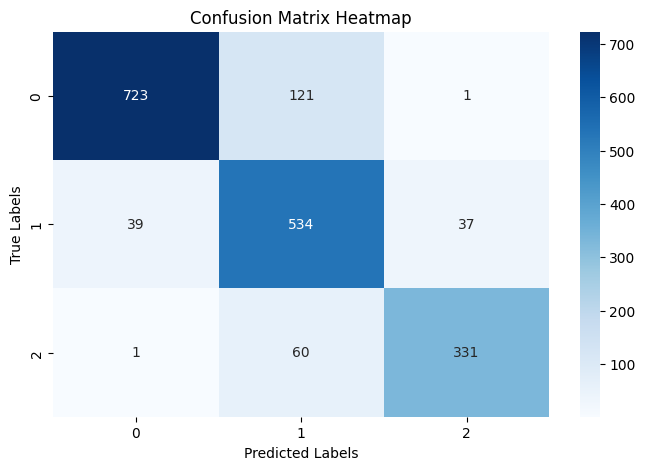

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# رسم نمودار حرارتی برای ماتریس سردرگمی
plt.figure(figsize=(8, 5))
sns.heatmap(a, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

## **Keras Classifier Model**

In [ ]:
pip install pytorch-forecasting

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.9/181.9 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 811.0/811.0 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 926.4/926.4 kB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 815.2/815.2 kB 35.3 MB/s eta 0:00:00


In [ ]:
pip install scikeras

In [ ]:
import yfinance as yf
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np
from sklearn.metrics import accuracy_score
# Scale features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)


In [ ]:

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features_scaled, label, test_size=0.3, random_state=42)
import time
start_time = time.time()

# Step 4: Build the Keras model
def build_model():
    model = Sequential()
    model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))  # First hidden layer
    model.add(Dense(32, activation='relu'))  # Second hidden layer
    model.add(Dense(3, activation='softmax'))  # Output layer with sigmoid for binary classification
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Step 5: Wrap the Keras model with KerasClassifier
model = KerasClassifier(model=build_model, epochs=20, batch_size=32, verbose=1)

# Step 6: Train the model
model.fit(X_train, y_train)

# Step 7: Evaluate the model
y_pred = model.predict(X_test)
end_time = time.time()
prediction_time = end_time - start_time
print("Time taken for prediction:", prediction_time, "seconds")
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy}")


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4564 - loss: 1.0597
Epoch 2/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4363 - loss: 1.0289
Epoch 3/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4591 - loss: 0.9852
Epoch 4/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5452 - loss: 0.9043
Epoch 5/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6606 - loss: 0.7988
Epoch 6/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7346 - loss: 0.6998
Epoch 7/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7874 - loss: 0.6292
Epoch 8/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7808 - loss: 0.5879
Epoch 9/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7849 - loss: 0.5574
Epoch 10/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8300 - loss: 0.5018
Epoch 11/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8340 - loss: 0.4761
Epoch 12/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, f1_score, precision_score ,recall_score

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
print("F1 Score =", f1)

# Calculate precision
precision = precision_score(y_test, y_pred, average='weighted')
print("Precision =", precision)
# Calculate F1 score
#f1 = f1_score(y_test, y_hat)
#print( "F1_Score =" , f1)
# Calculate precision
#precision = precision_score(y_test, y_hat)
#print("precision = ",precision )
print(f"Accuracy: {accuracy}")
#print(f"F1 Score: {f1}")
#print(f"Precision: {precision}")
#print(df["label"])

recall=recall_score(y_test, y_pred, average='weighted')
print("recall",recall)



F1 Score = 0.8846349934646108
Precision = 0.8846252644505396
Accuracy: 0.8846778559826746
recall 0.8846778559826746


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
y_pred = model.predict(X_test)

# محاسبه دقت
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

# ماتریس گیج و گزارش طبقه‌بندی
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Confusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy: 0.8846778559826746
Confusion Matrix:
[[781  63   1]
 [ 68 505  37]
 [  2  42 348]]

Classification Report:
              precision    recall  f1-score   support

          -1       0.92      0.92      0.92       845
           0       0.83      0.83      0.83       610
           1       0.90      0.89      0.89       392

    accuracy                           0.88      1847
   macro avg       0.88      0.88      0.88      1847
weighted avg       0.88      0.88      0.88      1847



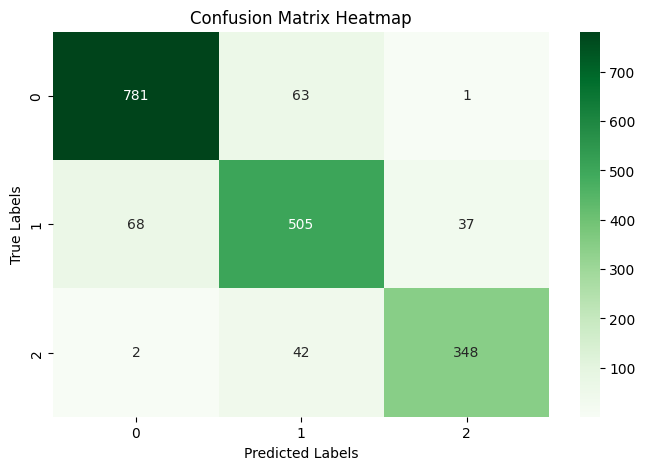

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# رسم نمودار حرارتی برای ماتریس سردرگمی
plt.figure(figsize=(8, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens')

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

## **ELM Model**

In [ ]:
pip install scikit-elm

In [ ]:
pip install dask[distributed]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.0 MB/s eta 0:00:00


In [ ]:

import yfinance as yf
import pandas as pd

def download_daily_data_with_1h_intervals(ticker, start_date, end_date):
    data = yf.download(ticker, start=start_date, end=end_date, interval='1h' , period="1d")
    return data

forex_ticker = 'EURUSD=X'  # Replace with the desired Forex pair, e.g., US Dollar to Euro
start_date = '2023-04-01'
end_date = '2024-04-01'

df = download_daily_data_with_1h_intervals(forex_ticker, start_date, end_date)

print(df.head())
df.shape[0]
df.isnull().sum().sum()

[*********************100%***********************]  1 of 1 completed

Price                     Adj Close     Close      High       Low      Open  \
Ticker                     EURUSD=X  EURUSD=X  EURUSD=X  EURUSD=X  EURUSD=X   
Datetime                                                                      
2023-04-02 23:00:00+00:00  1.080614  1.080614  1.082837  1.080497  1.082837   
2023-04-03 00:00:00+00:00  1.081783  1.081783  1.081783  1.080380  1.080614   
2023-04-03 01:00:00+00:00  1.081198  1.081198  1.081900  1.080731  1.081549   
2023-04-03 02:00:00+00:00  1.079797  1.079797  1.081198  1.079564  1.081198   
2023-04-03 03:00:00+00:00  1.079331  1.079331  1.080030  1.079214  1.079914   

Price                       Volume  
Ticker                    EURUSD=X  
Datetime                            
2023-04-02 23:00:00+00:00        0  
2023-04-03 00:00:00+00:00        0  
2023-04-03 01:00:00+00:00        0  
2023-04-03 02:00:00+00:00        0  
2023-04-03 03:00:00+00:00        0  


0

In [ ]:
df.columns = [col[0] for col in df.columns]

# Calculate returns
df['Return'] = (df['Close'] - df['Close'].shift(1)) / df['Close'].shift(1)
df = df.dropna()

print(df)

                           Adj Close     Close      High       Low      Open  \
Datetime                                                                       
2023-04-03 00:00:00+00:00   1.081783  1.081783  1.081783  1.080380  1.080614   
2023-04-03 01:00:00+00:00   1.081198  1.081198  1.081900  1.080731  1.081549   
2023-04-03 02:00:00+00:00   1.079797  1.079797  1.081198  1.079564  1.081198   
2023-04-03 03:00:00+00:00   1.079331  1.079331  1.080030  1.079214  1.079914   
2023-04-03 04:00:00+00:00   1.079564  1.079564  1.080030  1.079331  1.079331   
...                              ...       ...       ...       ...       ...   
2024-03-29 17:00:00+00:00   1.079214  1.079214  1.079214  1.079098  1.079098   
2024-03-29 18:00:00+00:00   1.079214  1.079214  1.079331  1.079098  1.079098   
2024-03-29 19:00:00+00:00   1.079331  1.079331  1.079564  1.079098  1.079214   
2024-03-29 20:00:00+00:00   1.079680  1.079680  1.080030  1.079098  1.079331   
2024-03-29 21:00:00+00:00   1.079680  1.

In [ ]:
df["label"] = 0
for i in range(1, len(df)):
    if df.loc[df.index[i], "Return"] >= 0.0005:
        df.loc[df.index[i], "label"] = 1
    elif (0 < df.loc[df.index[i], "Return"]) and (df.loc[df.index[i], "Return"] < 0.0005):
        df.loc[df.index[i], "label"] = 0
    elif df.loc[df.index[i], "Return"] < 0:
        df.loc[df.index[i], "label"] = -1


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
features = df[['Close' ,"Open" , "Low" ,"High" ]]
label=df["label"]
X_train, X_test, y_train, y_test = train_test_split(features,label, test_size=0.3, random_state=42)
import time
start_time = time.time()


In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# اینجا ی کلاس برای ELM تعریف کردیم
class ELM:
    def __init__(self, input_size, hidden_size, output_size):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.W = np.random.randn(input_size, hidden_size)  # Random weights
        self.beta = None

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def fit(self, X, y):
        H = self.sigmoid(np.dot(X, self.W))
        H_pinv = np.linalg.pinv(H)
        self.beta = np.dot(H_pinv, y)

    def predict(self, X):
        H = self.sigmoid(np.dot(X, self.W))
        return np.dot(H, self.beta)

num_classes = 3  # For classes -1, 0, and 1
y_train_oh = np.zeros((y_train.size, num_classes))

# Map labels -1, 0, 1 to indices 0, 1, 2 for one-hot encoding this is problem for some deeplearning model that need positive label
y_train_mapped = y_train + 1  # This will map -1 to 0, 0 to 1, and 1 to 2
y_train_oh[np.arange(y_train.size), y_train_mapped] = 1
# Convert labels to one-hot encoding


# Define and train the model
elm = ELM(input_size=X_train_scaled.shape[1], hidden_size=10, output_size=3)
elm.fit(X_train_scaled, y_train_oh)

# Predict and evaluate
y_pred = elm.predict(X_test_scaled)
y_pred_class = np.argmax(y_pred, axis=1) - 1  # Convert back to labels -1, 0, 1
accuracy = accuracy_score(y_test, y_pred_class)
print(f"Accuracy: {accuracy}")


Accuracy: 0.8050893340552246


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, f1_score, precision_score ,recall_score

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_class)
f1 = f1_score(y_test, y_pred_class, average='weighted')
print("F1 Score =", f1)

# Calculate precision
precision = precision_score(y_test, y_pred_class, average='weighted')
print("Precision =", precision)
# Calculate F1 score
#f1 = f1_score(y_test, y_hat)
#print( "F1_Score =" , f1)
# Calculate precision
#precision = precision_score(y_test, y_hat)
#print("precision = ",precision )
print(f"Accuracy: {accuracy}")
#print(f"F1 Score: {f1}")
#print(f"Precision: {precision}")
#print(df["label"])

recall=recall_score(y_test,y_pred_class, average='weighted')
print("recall",recall)



F1 Score = 0.8026982608262798
Precision = 0.804638101467138
Accuracy: 0.8050893340552246
recall 0.8050893340552246


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# تبدیل پیش‌بینی‌های پیوسته به برچسب‌های گسسته
y_pred_class = np.argmax(y_pred, axis=1) - 1  # برچسب‌ها به -1, 0, 1 تبدیل شوند

# محاسبه دقت و ماتریس گیج
accuracy = accuracy_score(y_test, y_pred_class)
conf_matrix = confusion_matrix(y_test, y_pred_class)
class_report = classification_report(y_test, y_pred_class)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)


Accuracy: 0.8050893340552246
Confusion Matrix:
[[779  63   3]
 [135 430  45]
 [  7 107 278]]

Classification Report:
              precision    recall  f1-score   support

          -1       0.85      0.92      0.88       845
           0       0.72      0.70      0.71       610
           1       0.85      0.71      0.77       392

    accuracy                           0.81      1847
   macro avg       0.81      0.78      0.79      1847
weighted avg       0.80      0.81      0.80      1847



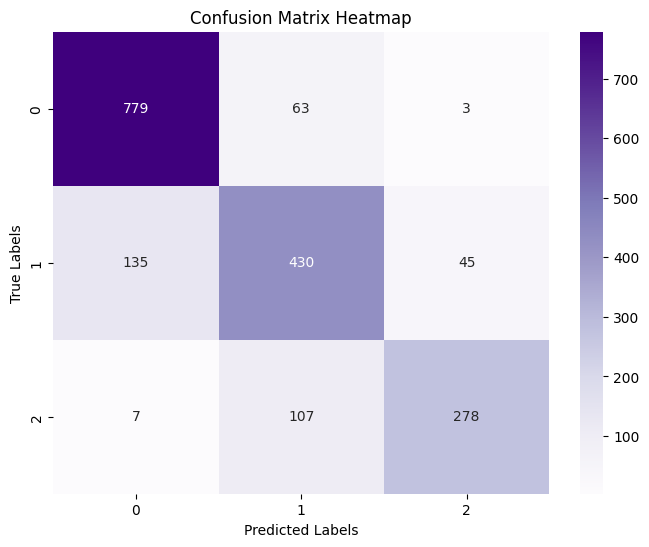

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# رسم نمودار حرارتی برای ماتریس سردرگمی
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Purples')

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [ ]:
pip install pytorch_forecasting

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.9/181.9 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 811.0/811.0 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 926.4/926.4 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 815.2/815.2 kB 27.4 MB/s eta 0:00:00


## TFT Model

In [ ]:
import numpy as np
import pandas as pd
from pytorch_forecasting.data import TimeSeriesDataSet
from pytorch_forecasting.metrics import CrossEntropy
from pytorch_forecasting.models.temporal_fusion_transformer import TemporalFusionTransformer
from pytorch_lightning import Trainer, LightningModule
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import torch

# --- 1. بارگذاری و آماده‌سازی داده‌ها ---
file_path = "/content/forex_data1.xlsx"  # مسیر فایل داده
df = pd.read_excel(file_path)

# پردازش داده‌ها
df['time_idx'] = np.arange(len(df))  # افزودن اندیس زمانی
df["group_id"] = "EURUSD"  # یک مقدار ثابت برای گروه‌بندی
df['Return'] = (df['Close'] - df['Close'].shift(1)) / df['Close'].shift(1)


In [ ]:

# تعریف ستون label بر اساس شرط‌ها
df["label"] = 0
df.loc[df["Return"] >= 0.0005, "label"] = 1
df.loc[(df["Return"] > 0) & (df["Return"] < 0.0005), "label"] = 0
df.loc[df["Return"] < 0, "label"] = -1

# انکود کردن برچسب‌ها به مقادیر صحیح
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["label"])

# ساخت ویژگی‌های جدید
for i in range(1, 6):
    for col in ["Open", "Low", "Close", "High"]:
        df[f"Shifted_{col}_{i}"] = df[col].shift(i)

df.dropna(inplace=True)

In [ ]:
# انتخاب ویژگی‌ها
features = [
    'Close', 'Open', 'Low', 'High',
    'Shifted_Open_1', 'Shifted_Low_1', 'Shifted_Close_1', 'Shifted_High_1',
    'Shifted_Open_2', 'Shifted_Low_2', 'Shifted_Close_2', 'Shifted_High_2',
    'Shifted_Open_3', 'Shifted_Low_3', 'Shifted_Close_3', 'Shifted_High_3',
    'Shifted_Open_4', 'Shifted_Low_4', 'Shifted_Close_4', 'Shifted_High_4',
    'Shifted_Open_5', 'Shifted_Low_5', 'Shifted_Close_5', 'Shifted_High_5'
]

In [ ]:
# --- 2. تعریف TimeSeriesDataSet ---
max_encoder_length = 48  # طول دنباله برای ورودی
max_prediction_length = 24  # طول دنباله برای پیش‌بینی
import time
start_time = time.time()
dataset = TimeSeriesDataSet(
    df,
    time_idx="time_idx",
    target="label",  # هدف
    group_ids=["group_id"],
    time_varying_known_reals=features,
    time_varying_unknown_reals=["label"],  # هدف به‌عنوان ویژگی ناشناخته
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
)

# DataLoader برای آموزش
dataloader = dataset.to_dataloader(train=True, batch_size=64, num_workers=0)

# --- 3. تعریف مدل TFT ---
tft = TemporalFusionTransformer.from_dataset(
    dataset,
    hidden_size=5,
    lstm_layers=2,
    dropout=0.1,
    #learning_rate=1e-3,
    learning_rate=0.1,
    loss=CrossEntropy(),  # استفاده از CrossEntropyLoss برای طبقه‌بندی
)


Exception ignored on calling ctypes callback function: <function ExecutionEngine._raw_object_cache_notify at 0x7a5e92f3a9e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/llvmlite/binding/executionengine.py", line 178, in _raw_object_cache_notify
    def _raw_object_cache_notify(self, data):
KeyboardInterrupt: 
/usr/local/lib/python3.10/dist-packages/lightning/pytorch/utilities/parsing.py:208: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.10/dist-packages/lightning/pytorch/utilities/parsing.py:208: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
/usr/local/lib/python3.10/dist-packages/pytorch_forecasting/models/temporal_fusion_transformer/__init__.py:171

In [ ]:

# --- 4. تعریف LightningModule ---
class TFTLightningModule(LightningModule):
    def __init__(self, tft_model):
        super().__init__()
        self.tft_model = tft_model

    def forward(self, x):
        return self.tft_model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch

        # انتقال داده‌ها به دستگاه
        x = {k: v.to(self.device) for k, v in x.items()}
        if isinstance(y, tuple):
            y = y[0]
        y = y.to(self.device)

        # پیش‌بینی و محاسبه Loss
        y_hat = self.tft_model(x)
        loss = self.tft_model.loss(y_hat["prediction"], y)
        self.log("train_loss", loss)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-3)


# --- 5. آموزش ---
# اینجا مدل TFTLightningModule را از مدل TFT ایجاد می‌کنیم
lightning_model = TFTLightningModule(tft)

trainer = Trainer(
    max_epochs=5,
    devices=1,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    logger=False,
    enable_checkpointing=False,
)

# آموزش مدل
trainer.fit(lightning_model, train_dataloaders=dataloader)
end_time = time.time()
prediction_time = end_time - start_time

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type                      | Params | Mode 
----------------------------------------------------------------
0 | tft_model | TemporalFusionTransformer | 24.7 K | train
----------------------------------------------------------------
24.7 K    Trainable params
0         Non-trainable params
24.7 K    Total params
0.099     Total estimated model params size (MB)
663       Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


In [ ]:

# --- 6. پیش‌بینی ---
predictions = []
actual_values = []

for batch in dataloader:
    x, y = batch

    # انتقال داده‌ها به دستگاه مناسب
    x = {k: v.to(lightning_model.device) for k, v in x.items()}
    if isinstance(y, tuple):
        y = y[0]
    y = y.to(lightning_model.device)

    with torch.no_grad():
        y_hat = tft(x)["prediction"].argmax(dim=1)
    predictions.append(y_hat.cpu().numpy())
    actual_values.append(y.cpu().numpy())

# تبدیل به numpy array
predicted_values = np.concatenate(predictions).flatten()
actual_values = np.concatenate(actual_values).flatten()

# محاسبه دقت

# --- همگام‌سازی داده‌ها ---
min_length = min(len(predicted_values), len(actual_values))
predicted_values = predicted_values[:min_length]
actual_values = actual_values[:min_length]

# تبدیل پیش‌بینی‌ها و مقادیر واقعی به کلاس‌ها
predicted_classes = (predicted_values > 0).astype(int)  # پیش‌بینی به کلاس‌ها
actual_classes = (actual_values > 0).astype(int)  # مقادیر واقعی به کلاس‌ها

# --- محاسبه دقت ---
accuracy = accuracy_score(actual_classes, predicted_classes)
print(f"Accuracy: {accuracy:.4f}")

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# Calculate Accuracy
accuracy = accuracy_score(actual_classes, predicted_classes)

# Calculate Precision
precision = precision_score(actual_classes, predicted_classes, average='weighted')  # 'weighted' handles multi-class

# Calculate Recall
recall = recall_score(actual_classes, predicted_classes, average='weighted')  # 'weighted' handles multi-class

# Calculate F1 Score
f1 = f1_score(actual_classes,predicted_classes, average='weighted')  # 'weighted' handles multi-class

# Displaying the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("Time taken for prediction:", prediction_time, "seconds")

Accuracy: 0.5437
Accuracy: 0.5437
Precision: 0.5021
Recall: 0.5437
F1 Score: 0.4142
Time taken for prediction: 225.89698839187622 seconds


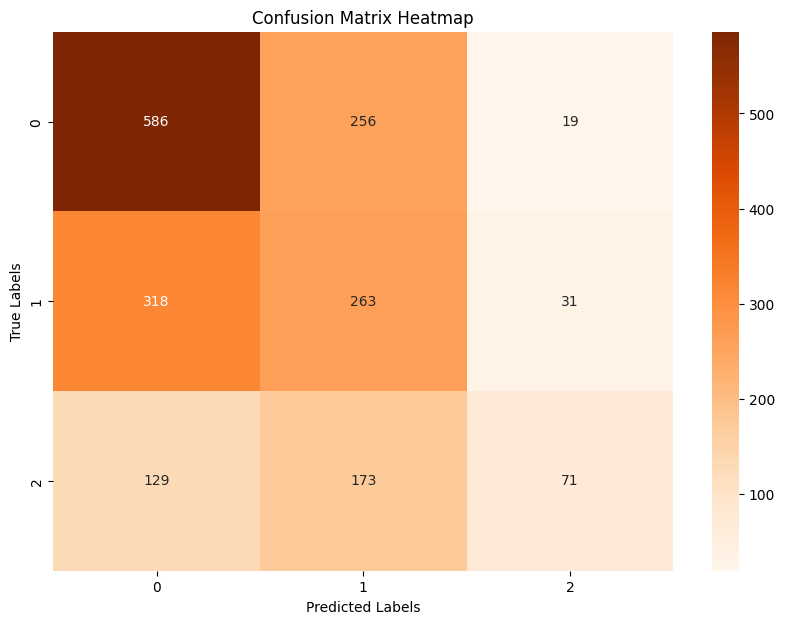

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Oranges')

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

## **Phlinet Model**

In [ ]:

# دانلود داده‌ها
def download_daily_data_with_1h_intervals(ticker, start_date, end_date):
    data = yf.download(ticker, start=start_date, end=end_date, interval='1h')
    return data

# داده‌ها
forex_ticker = 'EURUSD=X'
start_date = '2023-04-01'
end_date = "2024-04-01"
df = download_daily_data_with_1h_intervals(forex_ticker, start_date, end_date)

# پیش‌پردازش داده‌ها
df['Return'] = (df['Close'] - df['Close'].shift(1)) / df['Close'].shift(1)
df.dropna(inplace=True)
df['label'] = 0
df.loc[df['Return'] >= 0.0005, 'label'] = 1
df.loc[df['Return'] < 0, 'label'] = 2


[*********************100%***********************]  1 of 1 completed


In [ ]:
import yfinance as yf
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, precision_score, recall_score
features = df[['Open', 'High', 'Low', 'Close']].values
target = df['label'].values

scaler = StandardScaler()
features = scaler.fit_transform(features)

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42, shuffle=True)

X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)  # برای LSTM به حالت سری زمانی
X_test = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [ ]:

# تعریف مدل جدید با LSTM، FeedForward و Smooth Layer
class philnet(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super(philnet, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc1 = nn.Linear(hidden_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.smooth_layer = nn.Linear(64, num_classes)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        x = lstm_out[:, -1, :]  # آخرین خروجی LSTM
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.smooth_layer(x)
        return x

input_dim = X_train.shape[2]
hidden_dim = 128
num_classes = len(np.unique(y_train))

model = philnet(input_dim, hidden_dim, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [ ]:
from itertools import product
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# محدوده‌های جستجو برای هایپرپارامترها
param_grid = {
    'hidden_dim': [32, 64, 128],
    'lr': [0.001, 0.01],
    'batch_size': [16, 32, 64],
    'num_epochs': [20, 30]
}

# تولید ترکیب‌های مختلف از پارامترها
param_combinations = list(product(*param_grid.values()))

best_models = {
    'accuracy': {'score': 0, 'params': {}, 'model': None},
    'f1_score': {'score': 0, 'params': {}, 'model': None},
    'precision': {'score': 0, 'params': {}, 'model': None},
    'recall': {'score': 0, 'params': {}, 'model': None},
}

for params in param_combinations:
    hidden_dim, lr, batch_size, num_epochs = params
    print(f"Training with params: hidden_dim={hidden_dim}, lr={lr}, batch_size={batch_size}, num_epochs={num_epochs}")

    model = philnet(input_dim, hidden_dim, num_classes)  # فرض بر این است که مدل PhilNet تعریف شده است
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # آموزش مدل
    for epoch in range(num_epochs):
        model.train()
        permutation = torch.randperm(X_train.size()[0])
        for i in range(0, X_train.size()[0], batch_size):
            indices = permutation[i:i + batch_size]
            batch_x, batch_y = X_train[indices], y_train[indices]
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

    # ارزیابی مدل
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test)
        _, predicted = torch.max(test_outputs, 1)
        accuracy = accuracy_score(y_test, predicted)
        f1 = f1_score(y_test, predicted, average='weighted')
        precision = precision_score(y_test, predicted, average='weighted')
        recall = recall_score(y_test, predicted, average='weighted')

    # بررسی و به‌روزرسانی بهترین مدل برای هر معیار
    metrics = {
        'accuracy': accuracy,
        'f1_score': f1,
        'precision': precision,
        'recall': recall,
    }

    for metric, score in metrics.items():
        if score > best_models[metric]['score']:
            best_models[metric]['score'] = score
            best_models[metric]['params'] = {
                'hidden_dim': hidden_dim,
                'lr': lr,
                'batch_size': batch_size,
                'num_epochs': num_epochs
            }
            best_models[metric]['model'] = model

    print(f"Metrics for current params: Accuracy={accuracy}, F1 Score={f1}, Precision={precision}, Recall={recall}")

# نمایش بهترین پارامترها برای هر معیار
for metric, info in best_models.items():
    print(f"\nBest Parameters for {metric}:")
    print(info['params'])
    print(f"Best {metric.capitalize()}: {info['score']}")


Training with params: hidden_dim=32, lr=0.001, batch_size=16, num_epochs=20
Metrics for current params: Accuracy=0.8770979967514889, F1 Score=0.8780143876194481, Precision=0.8829871646161702, Recall=0.8770979967514889
Training with params: hidden_dim=32, lr=0.001, batch_size=16, num_epochs=30
Metrics for current params: Accuracy=0.8770979967514889, F1 Score=0.8774901394453265, Precision=0.8806159833129019, Recall=0.8770979967514889
Training with params: hidden_dim=32, lr=0.001, batch_size=32, num_epochs=20
Metrics for current params: Accuracy=0.8489442338927992, F1 Score=0.8456074549237539, Precision=0.8503317692415211, Recall=0.8489442338927992
Training with params: hidden_dim=32, lr=0.001, batch_size=32, num_epochs=30
Metrics for current params: Accuracy=0.879263670817542, F1 Score=0.880238332745424, Precision=0.8822378591039892, Recall=0.879263670817542
Training with params: hidden_dim=32, lr=0.001, batch_size=64, num_epochs=20
Metrics for current params: Accuracy=0.8565240931239848

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Metrics for current params: Accuracy=0.4574986464537087, F1 Score=0.28721126021796717, Precision=0.20930501150697553, Recall=0.4574986464537087
Training with params: hidden_dim=64, lr=0.01, batch_size=16, num_epochs=30
Metrics for current params: Accuracy=0.8088792636708175, F1 Score=0.8091766010395934, Precision=0.8112085151578708, Recall=0.8088792636708175
Training with params: hidden_dim=64, lr=0.01, batch_size=32, num_epochs=20
Metrics for current params: Accuracy=0.7969680563075258, F1 Score=0.8004994503137172, Precision=0.8095632474101868, Recall=0.7969680563075258
Training with params: hidden_dim=64, lr=0.01, batch_size=32, num_epochs=30
Metrics for current params: Accuracy=0.8798050893340552, F1 Score=0.8788692477529321, Precision=0.8788620851204354, Recall=0.8798050893340552
Training with params: hidden_dim=64, lr=0.01, batch_size=64, num_epochs=20
Metrics for current params: Accuracy=0.8170005414185165, F1 Score=0.8195507761180375, Precision=0.8414101190915719, Recall=0.81700

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Metrics for current params: Accuracy=0.4574986464537087, F1 Score=0.28721126021796717, Precision=0.20930501150697553, Recall=0.4574986464537087
Training with params: hidden_dim=128, lr=0.01, batch_size=32, num_epochs=20


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Metrics for current params: Accuracy=0.4574986464537087, F1 Score=0.28721126021796717, Precision=0.20930501150697553, Recall=0.4574986464537087
Training with params: hidden_dim=128, lr=0.01, batch_size=32, num_epochs=30
Metrics for current params: Accuracy=0.8478613968597726, F1 Score=0.8492696921676606, Precision=0.8521330455723188, Recall=0.8478613968597726
Training with params: hidden_dim=128, lr=0.01, batch_size=64, num_epochs=20
Metrics for current params: Accuracy=0.7661072008662696, F1 Score=0.7535338992094358, Precision=0.7761896760752733, Recall=0.7661072008662696
Training with params: hidden_dim=128, lr=0.01, batch_size=64, num_epochs=30
Metrics for current params: Accuracy=0.8673524634542501, F1 Score=0.8691672525826178, Precision=0.8750411328622802, Recall=0.8673524634542501

Best Parameters for accuracy:
{'hidden_dim': 32, 'lr': 0.01, 'batch_size': 64, 'num_epochs': 20}
Best Accuracy: 0.8863021115322144

Best Parameters for f1_score:
{'hidden_dim': 32, 'lr': 0.01, 'batch_s

In [ ]:
cm = confusion_matrix(y_test, predicted)
report = classification_report(y_test, predicted, target_names=['Class 0', 'Class 1', 'Class 2'])

print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(report)




Confusion Matrix:
[[527  44  39]
 [ 39 352   1]
 [121   1 723]]

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.77      0.86      0.81       610
     Class 1       0.89      0.90      0.89       392
     Class 2       0.95      0.86      0.90       845

    accuracy                           0.87      1847
   macro avg       0.87      0.87      0.87      1847
weighted avg       0.88      0.87      0.87      1847



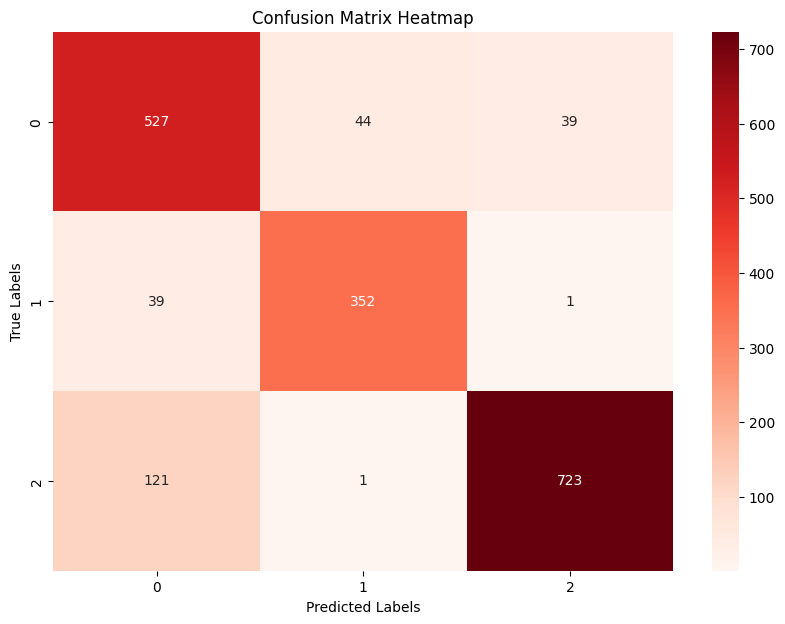

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# رسم نمودار حرارتی برای ماتریس سردرگمی
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()